# Beyond cosine similarity: one complete experimental notebook

This notebook consolidates the full mathematical and empirical analysis into a single, self-contained file.

It contains:

1. likelihood interpretations of MSE, MAE, Poisson deviance, and cosine alignment;
2. cosine, decos, and sign-preserving recos definitions;
3. the inequality hierarchy and rearrangement bound;
4. the group-action view through $O(d)$ and $S_d$;
5. permutohedra, Weyl chambers, stabilizers, and invariance groups;
6. probabilistic limits for Gaussian and nonlinear paired coordinates;
7. random-vector asymptotics and finite-dimensional inflation;
8. common-rotation and basis-dependence diagnostics;
9. kernel and metric counterexamples;
10. the paper's reported STS benchmark table and detailed result diagnostics;
11. a reusable template for rotation tests on real embeddings.

Paper: [Xinbo Ai, *Beyond Cosine Similarity*](https://arxiv.org/abs/2602.05266).

The reported STS table is embedded directly below, so no external CSV or auxiliary notebook is required.


In [1]:
from pathlib import Path
import math, itertools
from io import StringIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ART = Path("artifacts")
ART.mkdir(exist_ok=True)
plt.rcParams.update({"figure.figsize": (8, 4.5), "axes.grid": True, "font.size": 11})
RNG = np.random.default_rng(12345)


# Embedded data transcribed from the paper's reported STS table.
PAPER_STS_CSV = r'''
model,dataset,decos,cosine,recos,gain_recos_minus_cos
Word2Vec,STS12,53.07,52.78,52.8,0.01999999999999602
Word2Vec,STS13,69.63,70.12,70.14,0.01999999999999602
Word2Vec,STS14,65.42,65.74,65.77,0.030000000000001137
Word2Vec,STS15,75.19,75.54,75.55,0.009999999999990905
Word2Vec,STS16,67.09,67.69,67.69,0.0
Word2Vec,STS-B,64.3,64.51,64.53,0.01999999999999602
Word2Vec,SICK-R,57.83,58.0,58.06,0.060000000000002274
FastText,STS12,58.41,58.55,58.55,0.0
FastText,STS13,71.22,71.66,71.98,0.3200000000000074
FastText,STS14,64.69,65.23,65.58,0.3499999999999943
FastText,STS15,73.49,74.03,74.37,0.3400000000000034
FastText,STS16,63.95,64.49,64.79,0.30000000000001137
FastText,STS-B,63.7,63.99,64.32,0.3299999999999912
FastText,SICK-R,56.48,56.62,56.71,0.09000000000000341
GloVe,STS12,57.35,57.49,57.68,0.18999999999999773
GloVe,STS13,70.75,70.99,71.37,0.38000000000000966
GloVe,STS14,59.84,60.7,61.44,0.7399999999999949
GloVe,STS15,70.42,70.85,71.09,0.2400000000000091
GloVe,STS16,63.41,63.84,64.14,0.29999999999999716
GloVe,STS-B,50.41,50.74,51.29,0.5499999999999972
GloVe,SICK-R,55.31,55.42,55.62,0.19999999999999574
BERT,STS12,72.54,72.52,72.52,0.0
BERT,STS13,77.93,78.05,78.3,0.25
BERT,STS14,73.73,73.86,74.01,0.15000000000000568
BERT,STS15,79.43,79.48,79.66,0.1799999999999926
BERT,STS16,74.43,74.47,74.57,0.09999999999999432
BERT,STS-B,76.71,76.74,76.82,0.0799999999999983
BERT,SICK-R,73.53,73.54,73.64,0.09999999999999432
SGPT,STS12,66.27,66.44,66.54,0.10000000000000853
SGPT,STS13,69.96,70.13,70.15,0.020000000000010232
SGPT,STS14,63.5,63.71,63.79,0.0799999999999983
SGPT,STS15,75.29,75.54,75.58,0.03999999999999204
SGPT,STS16,71.6,71.75,71.75,0.0
SGPT,STS-B,72.69,72.89,72.92,0.030000000000001137
SGPT,SICK-R,67.68,68.0,68.08,0.0799999999999983
DPR,STS12,47.92,47.96,49.09,1.1300000000000026
DPR,STS13,63.88,63.97,64.11,0.14000000000000057
DPR,STS14,53.16,53.22,53.74,0.5200000000000031
DPR,STS15,67.21,67.25,67.4,0.15000000000000568
DPR,STS16,66.55,66.7,67.28,0.5799999999999983
DPR,STS-B,58.46,58.53,59.22,0.6899999999999977
DPR,SICK-R,62.39,62.45,63.78,1.3299999999999983
E5,STS12,60.42,60.42,60.7,0.28000000000000114
E5,STS13,70.0,70.0,70.16,0.1599999999999966
E5,STS14,65.3,65.3,65.44,0.14000000000000057
E5,STS15,74.92,74.92,75.05,0.12999999999999545
E5,STS16,77.43,77.43,77.44,0.009999999999990905
E5,STS-B,73.53,73.53,73.57,0.03999999999999204
E5,SICK-R,68.86,68.86,68.93,0.07000000000000739
BGE,STS12,49.97,49.97,50.28,0.3100000000000023
BGE,STS13,32.19,32.19,31.88,-0.3099999999999987
BGE,STS14,33.64,33.64,33.82,0.17999999999999972
BGE,STS15,35.01,35.01,35.12,0.10999999999999943
BGE,STS16,63.81,63.81,63.94,0.12999999999999545
BGE,STS-B,65.61,65.61,65.71,0.09999999999999432
BGE,SICK-R,57.94,57.94,57.99,0.05000000000000426
GTE,STS12,74.81,74.82,75.0,0.18000000000000682
GTE,STS13,86.63,86.64,86.77,0.12999999999999545
GTE,STS14,78.74,78.76,78.98,0.21999999999999886
GTE,STS15,85.38,85.39,85.5,0.10999999999999943
GTE,STS16,83.1,83.1,83.17,0.07000000000000739
GTE,STS-B,85.42,85.42,85.45,0.030000000000001137
GTE,SICK-R,75.72,75.72,75.72,0.0
SPECTER,STS12,62.45,62.49,63.01,0.519999999999996
SPECTER,STS13,58.62,58.7,59.7,1.0
SPECTER,STS14,54.82,54.87,55.45,0.5800000000000054
SPECTER,STS15,62.49,62.54,63.1,0.5600000000000023
SPECTER,STS16,64.27,64.28,64.47,0.18999999999999773
SPECTER,STS-B,61.23,61.26,61.5,0.240000000000002
SPECTER,SICK-R,56.36,56.39,56.71,0.3200000000000003
CLIP-ViT,STS12,76.71,76.92,77.39,0.46999999999999886
CLIP-ViT,STS13,63.1,63.96,64.81,0.8500000000000014
CLIP-ViT,STS14,57.15,57.98,59.34,1.3600000000000065
CLIP-ViT,STS15,65.58,66.19,67.55,1.3599999999999994
CLIP-ViT,STS16,72.08,72.41,72.78,0.37000000000000455
CLIP-ViT,STS-B,64.8,65.29,66.53,1.2399999999999949
CLIP-ViT,SICK-R,69.89,70.53,71.61,1.0799999999999983
'''
paper = pd.read_csv(StringIO(PAPER_STS_CSV))
paper.head()


,model,dataset,decos,cosine,recos,gain_recos_minus_cos
0,Word2Vec,STS12,53.07,52.78,52.80,0.02
1,Word2Vec,STS13,69.63,70.12,70.14,0.02
2,Word2Vec,STS14,65.42,65.74,65.77,0.03
3,Word2Vec,STS15,75.19,75.54,75.55,0.01
4,Word2Vec,STS16,67.09,67.69,67.69,0.00


## 1. Definitions

For $u,v\in\mathbb R^d$, define the observed alignment $S(u,v)=u^\top v$. The three normalizations used here are

$$
\mathrm{decos}(u,v)=\frac{u^\top v}{\tfrac12(\|u\|^2+\|v\|^2)},
\qquad
\cos(u,v)=\frac{u^\top v}{\|u\|\|v\|},
$$

and the sign-preserving rearrangement score

$$
\mathrm{recos}(u,v)=
\begin{cases}
\dfrac{u^\top v}{\langle u^\uparrow,v^\uparrow\rangle}, & u^\top v>0,\\[0.8em]
\dfrac{u^\top v}{|\langle u^\uparrow,v^\downarrow\rangle|}, & u^\top v<0,\\[0.4em]
0,&u^\top v=0.
\end{cases}
$$


In [2]:
def cosine(u, v):
    u, v = np.asarray(u, float), np.asarray(v, float)
    den = np.linalg.norm(u) * np.linalg.norm(v)
    return float(np.dot(u, v) / den) if den else 0.0

def decos(u, v):
    u, v = np.asarray(u, float), np.asarray(v, float)
    den = 0.5 * (np.dot(u, u) + np.dot(v, v))
    return float(np.dot(u, v) / den) if den else 0.0

def recos(u, v):
    u, v = np.asarray(u, float), np.asarray(v, float)
    s = float(np.dot(u, v))
    if abs(s) < 1e-15:
        return 0.0
    us, vs = np.sort(u), np.sort(v)
    max_dot = float(np.dot(us, vs))
    min_dot = float(np.dot(us, vs[::-1]))
    den = abs(max_dot) if s > 0 else abs(min_dot)
    return s / den if den > 1e-15 else 0.0

def recos_batch(U, V):
    U, V = np.asarray(U, float), np.asarray(V, float)
    dot = np.einsum("ij,ij->i", U, V)
    Us, Vs = np.sort(U, axis=1), np.sort(V, axis=1)
    max_dot = np.einsum("ij,ij->i", Us, Vs)
    min_dot = np.einsum("ij,ij->i", Us, Vs[:, ::-1])
    den = np.where(dot >= 0, np.abs(max_dot), np.abs(min_dot))
    return np.divide(dot, den, out=np.zeros_like(dot), where=den > 1e-15)


In [3]:
u = np.array([-1.5, -0.8, -0.2, 0.4, 1.1, 1.7])
examples = {
    "linear": 2*u,
    "monotone cubic": u**3,
    "permuted": u[[2,0,5,1,4,3]],
    "decreasing cubic": -(u**3),
    "independent random": RNG.normal(size=len(u)),
}
pd.DataFrame({
    name: {"decos": decos(u,v), "cosine": cosine(u,v), "recos": recos(u,v)}
    for name,v in examples.items()
}).T


,decos,cosine,recos
linear,0.800000,1.000000,1.000000
monotone cubic,0.684399,0.931899,1.000000
permuted,0.379694,0.379694,0.379694
decreasing cubic,-0.684399,-0.931899,-1.000000
independent random,-0.024137,-0.024534,-0.026963


## 2. Why familiar losses have probabilistic stories

A useful way to justify a loss is to specify a likelihood.

* Fixed-variance Gaussian residuals give squared error.
* Fixed-scale Laplace residuals give absolute error.
* Poisson observations give Poisson negative log-likelihood, not absolute error.
* For unit vectors, the von Mises--Fisher density $p(x\mid\mu,\kappa)\propto\exp(\kappa\mu^Tx)$ gives negative cosine as the loss when $\kappa$ is fixed.

The last point gives cosine a likelihood interpretation. It still assumes the sphere and its orthogonal symmetry are the correct geometry for the representation.


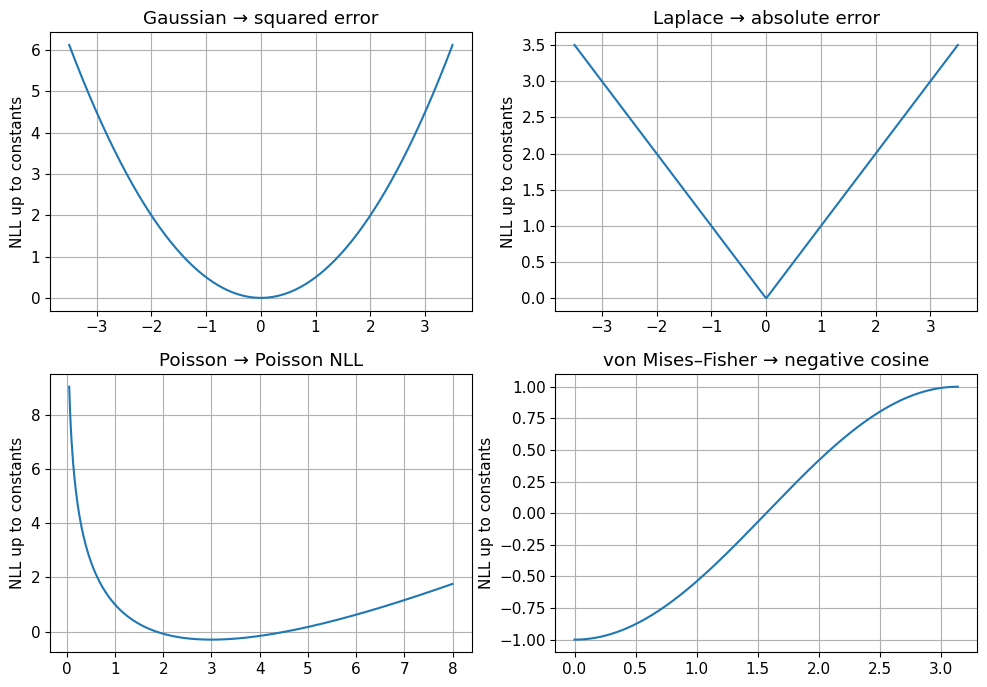

In [4]:
r = np.linspace(-3.5, 3.5, 500)
fig, axs = plt.subplots(2,2,figsize=(10,7))
axs[0,0].plot(r, .5*r*r); axs[0,0].set_title("Gaussian → squared error")
axs[0,1].plot(r, np.abs(r)); axs[0,1].set_title("Laplace → absolute error")
lam=np.linspace(.05,8,500); y=3
axs[1,0].plot(lam,lam-y*np.log(lam)); axs[1,0].set_title("Poisson → Poisson NLL")
theta=np.linspace(0,np.pi,500)
axs[1,1].plot(theta,-np.cos(theta)); axs[1,1].set_title("von Mises–Fisher → negative cosine")
for ax in axs.flat: ax.set_ylabel("NLL up to constants")
plt.tight_layout(); plt.show()


## 3. The inequality hierarchy

The rearrangement and Cauchy--Schwarz inequalities give

$$
|u^Tv|\leq \langle u^\uparrow,v^{\updownarrow}\rangle
\leq \|u\|\|v\|
\leq \tfrac12(\|u\|^2+\|v\|^2).
$$

A smaller valid denominator produces a score with a wider saturation set. This explains the pointwise hierarchy

$$|\mathrm{decos}|\leq|\cos|\leq|\mathrm{recos}|\leq1.$$


In [5]:
# Verify the rearrangement extrema by enumerating all permutations in d=6.
u = RNG.normal(size=6)
v = RNG.normal(size=6)
dots = [np.dot(u, v[list(p)]) for p in itertools.permutations(range(6))]
print("maximum:", max(dots), "sorted formula:", np.dot(np.sort(u), np.sort(v)))
print("minimum:", min(dots), "reverse formula:", np.dot(np.sort(u), np.sort(v)[::-1]))


maximum: 6.1666290452005255 sorted formula: 6.1666290452005255
minimum: -6.851139261336004 reverse formula: -6.851139261336005


## 4. Group actions and orbit normalization

The orthogonal group $O(d)$ acts by rotations and reflections. Its orbit through $v$ is the sphere of radius $\|v\|$, and

$$\sup_{Q\in O(d)}u^TQv=\|u\|\|v\|.$$

The symmetric group $S_d$ acts by coordinate permutations. Its orbit is finite, and its convex hull is the permutohedron:

$$\max_{\pi\in S_d}u^TP_\pi v=(u^\uparrow)^Tv^\uparrow.$$

Thus both scores fit the template

$$s_G(u,v)=\frac{u^Tv}{\text{best signed alignment of }u\text{ with the orbit }Gv}.$$

The metric is therefore a choice of symmetry group, not only a choice of denominator.


In [6]:
# Compare the sizes of the two orbit maxima.
for d in [3, 5, 10]:
    u, v = RNG.normal(size=d), RNG.normal(size=d)
    perm_max = np.dot(np.sort(u), np.sort(v))
    orth_max = np.linalg.norm(u) * np.linalg.norm(v)
    print(d, "permutation bound / orthogonal bound =", perm_max/orth_max)


3 permutation bound / orthogonal bound = -0.01771672820861622
5 permutation bound / orthogonal bound = 0.9086005956891811
10 permutation bound / orthogonal bound = 0.8255319520828591


## 5. Weyl chambers and ordinal saturation

The hyperplanes $x_i=x_j$ divide $\mathbb R^d$ into Weyl chambers of type $A_{d-1}$. Each open chamber corresponds to one strict coordinate ordering. If $u$ and $v$ lie in the same closed chamber and $u^Tv>0$, the identity permutation is optimal and recos equals one.

This is the precise sense in which recos captures nonlinear monotone relationships.


In [7]:
u=np.array([-1.5,-0.4,0.3,1.7])
rows=[]
for p in [1,1.5,2,3,5]:
    v=np.sign(u)*np.abs(u)**p
    rows.append({"power":p,"cosine":cosine(u,v),"recos":recos(u,v)})
pd.DataFrame(rows)


,power,cosine,recos
0,1.0,1.000000,1.0
1,1.5,0.993145,1.0
2,2.0,0.984156,1.0
3,3.0,0.971755,1.0
4,5.0,0.950531,1.0


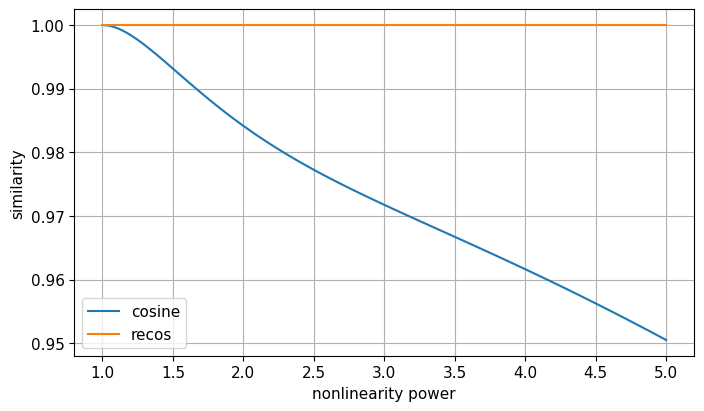

In [8]:
p=np.linspace(1,5,100)
cos_vals=[]; recos_vals=[]
for q in p:
    v=np.sign(u)*np.abs(u)**q
    cos_vals.append(cosine(u,v)); recos_vals.append(recos(u,v))
plt.plot(p,cos_vals,label="cosine")
plt.plot(p,recos_vals,label="recos")
plt.xlabel("nonlinearity power"); plt.ylabel("similarity"); plt.legend(); plt.show()


## 6. Population interpretation

Let $(U_i,V_i)$ be i.i.d. coordinate pairs with marginal quantile functions $q_F,q_G$. The permutation extrema converge to the extremal covariance couplings

$$c_+=\int_0^1q_F(t)q_G(t)\,dt,
\qquad
c_-=-\int_0^1q_F(t)q_G(1-t)\,dt.$$

If $\mu=\mathbb E[UV]>0$, then

$$\mathrm{recos}(U,V)\xrightarrow{p}\frac{\mu}{c_+}.$$

Cosine instead converges to covariance divided by the Cauchy--Schwarz scale. For $U\sim N(0,1)$ and $V=U^3$, recos tends to one while cosine tends to $3/\sqrt{15}\approx0.7746$.


In [9]:
rows=[]
for d in [32,128,512,2048,8192]:
    u=RNG.normal(size=d); v=u**3
    rows.append({"d":d,"cosine":cosine(u,v),"recos":recos(u,v)})
pd.DataFrame(rows)


,d,cosine,recos
0,32,0.877610,1.0
1,128,0.812810,1.0
2,512,0.781249,1.0
3,2048,0.788736,1.0
4,8192,0.775466,1.0


## 7. Independent random vectors

For independent isotropic directions, cosine has mean zero and variance $1/d$. Under symmetric i.i.d. coordinates, recos also has the same first-order $1/d$ second-moment scale. Its finite-dimensional magnitude is larger because it uses a smaller orbit maximum, but the difference shrinks with dimension.


In [10]:
def random_experiment(d, n=15000, seed=0):
    rng=np.random.default_rng(seed)
    U=rng.normal(size=(n,d)); V=rng.normal(size=(n,d))
    dot=np.einsum("ij,ij->i",U,V)
    c=dot/(np.linalg.norm(U,axis=1)*np.linalg.norm(V,axis=1))
    rr=recos_batch(U,V)
    return {"d":d,"E|cos|":np.abs(c).mean(),"E|recos|":np.abs(rr).mean(),"dEcos2":d*np.mean(c*c),"dErecos2":d*np.mean(rr*rr)}
random_df=pd.DataFrame([random_experiment(d, n=20000 if d<=32 else 9000, seed=d) for d in [2,4,8,16,32,64,128]])
random_df


,d,E|cos|,E|recos|,dEcos2,dErecos2
0,2,0.637684,0.889688,1.001087,1.700069
1,4,0.424460,0.568386,1.000021,1.683108
2,8,0.292987,0.351409,1.012887,1.426921
3,16,0.202059,0.224534,0.996238,1.220849
4,32,0.142831,0.151486,1.006786,1.130346
5,64,0.099040,0.102247,0.977744,1.041113
6,128,0.071204,0.072450,1.009666,1.044616


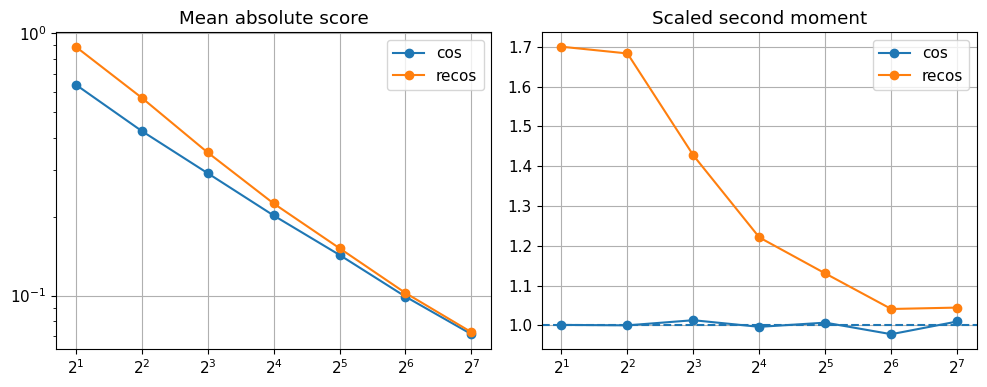

In [11]:
fig,axs=plt.subplots(1,2,figsize=(10,4))
axs[0].plot(random_df.d,random_df["E|cos|"],"o-",label="cos")
axs[0].plot(random_df.d,random_df["E|recos|"],"o-",label="recos")
axs[0].set_xscale("log",base=2); axs[0].set_yscale("log"); axs[0].legend(); axs[0].set_title("Mean absolute score")
axs[1].plot(random_df.d,random_df.dEcos2,"o-",label="cos")
axs[1].plot(random_df.d,random_df.dErecos2,"o-",label="recos")
axs[1].axhline(1,ls="--"); axs[1].set_xscale("log",base=2); axs[1].legend(); axs[1].set_title("Scaled second moment")
plt.tight_layout(); plt.show()


## 8. Basis dependence

Cosine is invariant under a common orthogonal change of basis. Recos is invariant under simultaneous coordinate permutations and positive rescaling, but not under a general common rotation. This is the most important empirical diagnostic: does a model learn a privileged coordinate basis, or is the gain a coordinate artifact?


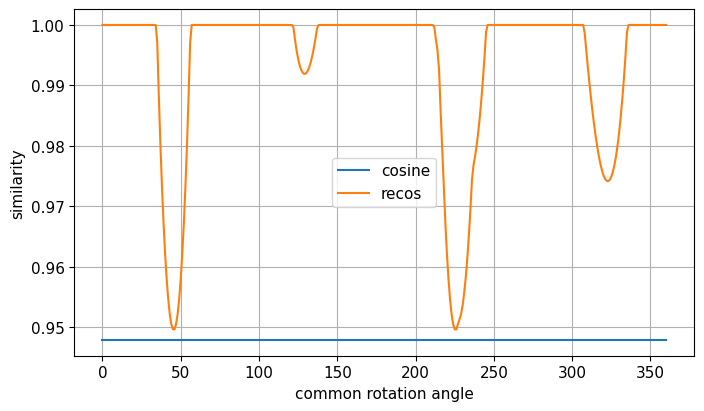

cosine range 0.94792487906726 0.9479248790672603
recos range 0.949683424540471 1.0000000000000002


In [12]:
u0=np.array([2.2,.4,-1.5]); v0=np.array([1.5,-.3,-.9])
theta=np.linspace(0,2*np.pi,361)
cs=[]; rs=[]
for t in theta:
    Q=np.array([[np.cos(t),-np.sin(t),0],[np.sin(t),np.cos(t),0],[0,0,1]])
    cs.append(cosine(Q@u0,Q@v0)); rs.append(recos(Q@u0,Q@v0))
plt.plot(np.degrees(theta),cs,label="cosine")
plt.plot(np.degrees(theta),rs,label="recos")
plt.xlabel("common rotation angle"); plt.ylabel("similarity"); plt.legend(); plt.show()
print("cosine range",min(cs),max(cs))
print("recos range",min(rs),max(rs))


## 9. Kernel and metric diagnostics

A similarity score need not be a positive-semidefinite kernel, and $1-s$ need not be a metric. The following three-vector example gives a recos Gram matrix with a negative eigenvalue and also violates the triangle inequality for $1-\mathrm{recos}$.


In [13]:
X=np.array([[-1,-1],[-1,0],[0,-1]],float)
K=np.array([[recos(a,b) for b in X] for a in X])
print(K)
print("eigenvalues:",np.linalg.eigvalsh(K))
left=1-recos(X[1],X[2])
right=(1-recos(X[1],X[0]))+(1-recos(X[0],X[2]))
print("triangle inequality check:",left,"<=",right,"?",left<=right)


[[1. 1. 1.]
 [1. 1. 0.]
 [1. 0. 1.]]
eigenvalues: [-0.41421356  1.          2.41421356]
triangle inequality check: 1.0 <= 0.0 ? False


## 10. Reported STS results

The CSV below transcribes Table 1 of the paper. The gain is small in absolute terms but unusually consistent. This is evidence that the ordinal signal may be useful, but it does not by itself establish basis-independent semantic geometry.


In [14]:
summary = paper.groupby("model")["gain_recos_minus_cos"].mean().sort_values()
summary


model
Word2Vec    0.022857
SGPT        0.050000
BGE         0.081429
GTE         0.105714
E5          0.118571
BERT        0.122857
FastText    0.247143
GloVe       0.371429
SPECTER     0.487143
DPR         0.648571
CLIP-ViT    0.961429
Name: gain_recos_minus_cos, dtype: float64

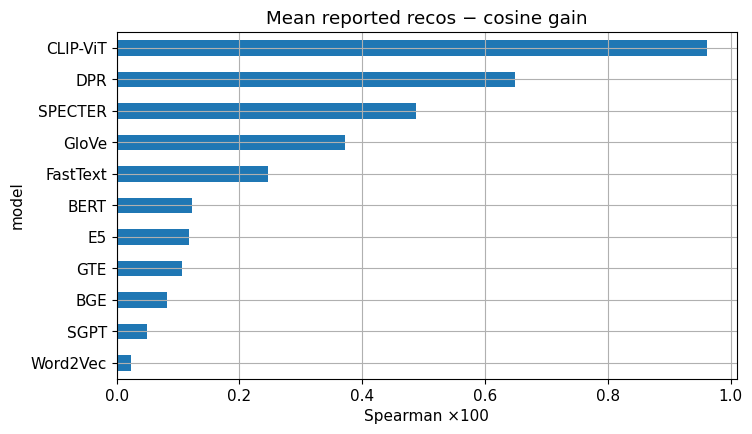

mean gain 0.2924675324675324
wins / ties / losses 71 5 1


In [15]:
summary.plot.barh(title="Mean reported recos − cosine gain")
plt.xlabel("Spearman ×100"); plt.show()
print("mean gain",paper.gain_recos_minus_cos.mean())
print("wins / ties / losses",(paper.gain_recos_minus_cos>0).sum(),(paper.gain_recos_minus_cos==0).sum(),(paper.gain_recos_minus_cos<0).sum())


## 11. Recommended follow-up experiments

1. Apply common Haar-random orthogonal rotations to all embeddings and repeat STS evaluation.
2. Compare raw and coordinate-centered recos.
3. Measure dimension scaling under Gaussian, Laplace, and heavy-tailed null models.
4. Study $V=g(U)+\varepsilon$ for nonlinear monotone $g$ and controlled noise.
5. Use coordinate-permutation null tests to check the exact group-average variance.
6. Inspect Gram-matrix eigenvalues before using recos in kernel or spectral algorithms.
7. Benchmark partial sorting, quantile sketches, and approximate ranks for large-scale retrieval.

The main conceptual lesson is that a similarity measure chooses a symmetry group. Recos is attractive when coordinates have a privileged, reproducible meaning. Cosine is safer when arbitrary orthogonal reparameterizations should leave the problem unchanged.


# Part II — detailed paper-result and rotation diagnostics

The remaining sections preserve the additional result-audit and basis-rotation material that previously lived in a separate notebook. They reuse the definitions and embedded `paper` table above.


## Reported aggregate


In [16]:
gain=paper.gain_recos_minus_cos
print("model–dataset pairs:",len(paper))
print("mean gain:",gain.mean())
print("wins / ties / losses:",(gain>0).sum(),(gain==0).sum(),(gain<0).sum())
paper.groupby("model").gain_recos_minus_cos.mean().sort_values()


model–dataset pairs: 77
mean gain: 0.2924675324675324
wins / ties / losses: 71 5 1


model
Word2Vec    0.022857
SGPT        0.050000
BGE         0.081429
GTE         0.105714
E5          0.118571
BERT        0.122857
FastText    0.247143
GloVe       0.371429
SPECTER     0.487143
DPR         0.648571
CLIP-ViT    0.961429
Name: gain_recos_minus_cos, dtype: float64

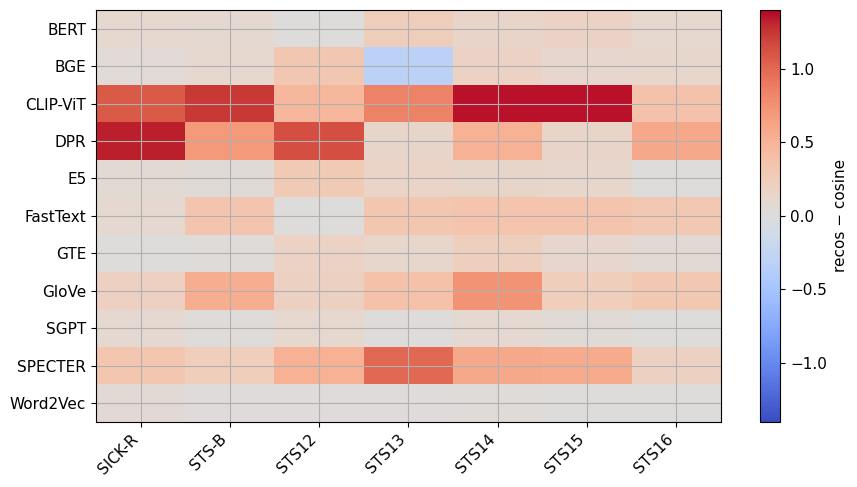

In [17]:
pivot=paper.pivot(index="model",columns="dataset",values="gain_recos_minus_cos")
fig,ax=plt.subplots(figsize=(9,5))
im=ax.imshow(pivot.values,aspect="auto",cmap="coolwarm",vmin=-1.4,vmax=1.4)
ax.set_xticks(range(len(pivot.columns)),pivot.columns,rotation=45,ha="right")
ax.set_yticks(range(len(pivot.index)),pivot.index)
fig.colorbar(im,ax=ax,label="recos − cosine")
plt.tight_layout();plt.show()


## Sign-preserving recos and common rotations

Cosine is invariant under a common orthogonal map. Recos generally changes because coordinate order changes.


In [18]:
def cosine(u,v):
    u=np.asarray(u,float);v=np.asarray(v,float)
    return np.dot(u,v)/(np.linalg.norm(u)*np.linalg.norm(v))

def recos(u,v):
    u=np.asarray(u,float);v=np.asarray(v,float);s=float(np.dot(u,v))
    if abs(s)<1e-15:return 0.0
    us,vs=np.sort(u),np.sort(v)
    den=abs(np.dot(us,vs)) if s>0 else abs(np.dot(us,vs[::-1]))
    return s/den if den>1e-15 else 0.0

def haar_orthogonal(d,rng):
    q,r=np.linalg.qr(rng.normal(size=(d,d)))
    q=q@np.diag(np.sign(np.diag(r)))
    return q


In [19]:
rng=np.random.default_rng(0)
u=np.array([2.2,.4,-1.5]);v=np.array([1.5,-.3,-.9])
rows=[]
for k in range(1000):
    Q=haar_orthogonal(3,rng)
    rows.append((cosine(Q@u,Q@v),recos(Q@u,Q@v)))
rot=pd.DataFrame(rows,columns=["cosine","recos"])
rot.describe()


,cosine,recos
count,1.000000e+03,1000.000000
mean,9.479249e-01,0.993274
std,1.215275e-16,0.013404
min,9.479249e-01,0.947979
25%,9.479249e-01,0.996047
50%,9.479249e-01,1.000000
75%,9.479249e-01,1.000000
max,9.479249e-01,1.000000


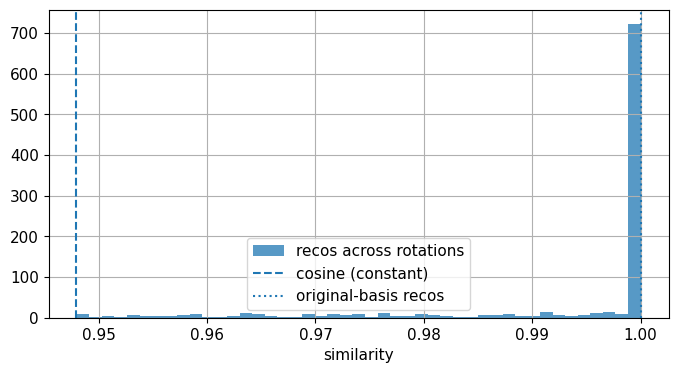

In [20]:
fig,ax=plt.subplots(figsize=(8,4))
ax.hist(rot.recos,bins=45,alpha=.75,label="recos across rotations")
ax.axvline(rot.cosine.iloc[0],ls="--",label="cosine (constant)")
ax.axvline(recos(u,v),ls=":",label="original-basis recos")
ax.set_xlabel("similarity");ax.legend();plt.show()


## Template for real embeddings

Given embedding matrices `A` and `B` with paired rows, repeatedly sample one common Haar-random orthogonal matrix, rotate both matrices, recompute the recos scores, and evaluate Spearman correlation with the same gold labels. The unrotated score can then be located in this null distribution.

```python
for seed in range(R):
    Q = haar_orthogonal(d, np.random.default_rng(seed))
    scores = recos_rows(A @ Q, B @ Q)
    rho[seed] = scipy.stats.spearmanr(scores, gold).statistic
```

A strong basis-specific claim should report the distribution, not only the unrotated value.
